### Important Libraries To Show

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter


### Loading the Image and Converting to Gray Scale

In [22]:
image = Image.open("pexels-alexravvas-26611787.jpg")
image = image.convert('L')

### Resizing the Image

In [23]:
image = image.resize((500,500))
image_array = np.array(image)

### Creating the Function for adding the NOise

In [24]:
def add_salt_pepper_noise(image, prob=0.02):
    noisy = image.copy()
    rows, cols = noisy.shape

    num_salt = int(prob * rows * cols)
    coords = [np.random.randint(0, i, num_salt) for i in (rows, cols)]
    noisy[coords[0], coords[1]] = 255

    num_pepper = int(prob * rows * cols)
    coords = [np.random.randint(0, i, num_pepper) for i in (rows, cols)]
    noisy[coords[0], coords[1]] = 0

    return noisy

noisy_img = add_salt_pepper_noise(image_array , 0.02)

### Applying Filter

In [25]:
noisy_pil = Image.fromarray(noisy_img)

filtered_img = noisy_pil.filter(ImageFilter.MedianFilter(size=3))


### Plotting the Images

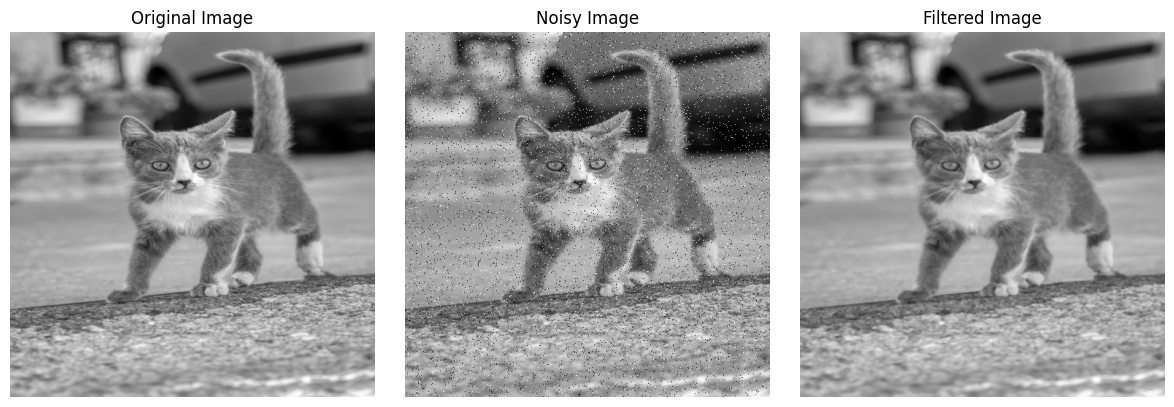

In [27]:
plt.figure(figsize=(12,4))

# Original
plt.subplot(1,3,1)
plt.imshow(image_array, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Noisy
plt.subplot(1,3,2)
plt.imshow(noisy_img, cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

# Filtered
plt.subplot(1,3,3)
plt.imshow(filtered_img, cmap='gray')
plt.title('Filtered Image')
plt.axis('off')

plt.tight_layout()
plt.show()